<a href="https://colab.research.google.com/github/IAmPiHi/Better-cd/blob/main/WEEK4LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# B11323035 張家銘 WEEK4 課堂LAB

##練習 1：參數的意義
執行完上述程式碼後，請印出 ```lin_regr``` 的 ```coef_``` (係數) 與 ```intercept_``` (截距)。

思考： 在線性公式
 中，哪一個對應到 ```coef_```？這代表特徵與目標之間的什麼關係？

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.867e+02, tolerance: 1.611e+01
  model = cd_fast.enet_coordinate_descent(


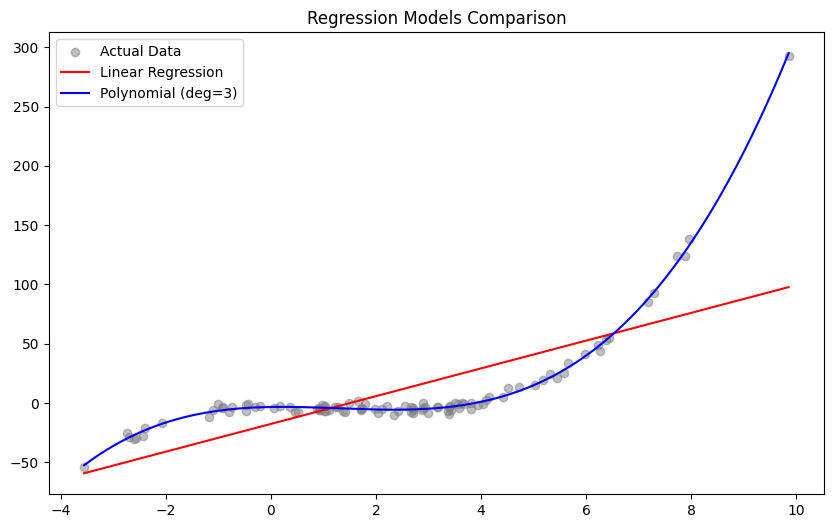

Linear Score: 0.1790
Polynomial Score: 0.9796


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 1. 產生模擬資料 (包含一些雜訊)
np.random.seed(42)
X = 2 - 3 * np.random.normal(0, 1, 100)
y = X - 2 * (X ** 2) + 0.5 * (X ** 3) + np.random.normal(-3, 3, 100)
X = X[:, np.newaxis] # 轉為 2D array 以符合 sklearn 要求

# 2. 資料切分 (80% 訓練, 20% 測試)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 實作：簡單線性迴歸 ---
lin_regr = linear_model.LinearRegression()
lin_regr.fit(X_train, y_train)

# --- 實作：多項式迴歸 (設定為 3 次方) ---
# 使用 Pipeline 簡化特徵轉換與迴歸流程
poly_model = make_pipeline(PolynomialFeatures(degree=3), linear_model.LinearRegression())
poly_model.fit(X_train, y_train)

# --- 實作：Lasso 正規化 (防止過度擬合) ---
lasso_model = make_pipeline(PolynomialFeatures(degree=10), linear_model.Lasso(alpha=1.0))
lasso_model.fit(X_train, y_train)

# 3. 視覺化比較
X_seq = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='gray', alpha=0.5, label='Actual Data')
plt.plot(X_seq, lin_regr.predict(X_seq), color='red', label='Linear Regression')
plt.plot(X_seq, poly_model.predict(X_seq), color='blue', label='Polynomial (deg=3)')
plt.legend()
plt.title("Regression Models Comparison")
plt.show()

# 4. 評估模型效能 (R-squared)
print(f"Linear Score: {lin_regr.score(X_test, y_test):.4f}")
print(f"Polynomial Score: {poly_model.score(X_test, y_test):.4f}")

In [ ]:
print(f"係數 (coef_): {lin_regr.coef_[0]:.4f}")
print(f"截距 (intercept_): {lin_regr.intercept_:.4f}")

係數 (coef_): 11.7062
截距 (intercept_): -17.6545


題目回答: **coef** 它代表特徵 $X$ 與目標 $y$ 之間的變化比例。如果 coef_ 是正值，代表兩者正相關；數值越大，代表 $X$ 對 $y$ 的影響力越強。<br>
也就是對應到:  $y = ax + b$ <br>
裡面的 $a$ 斜率

##練習 2：學習率與迭代


參考「回歸」講義中的「梯度下降法」，若我們手寫一個簡單的權重更新迴圈：
```python
# 假設 alpha 為學習率
w1 = w1 - alpha * gradient
```
請嘗試將 alpha 分別設為 0.1 與 0.00001，觀察模型收斂的速度。

為什麼在處理大數據時，使用 Stochastic Gradient Descent (SGD) 會比 Batch GD 更有效率？

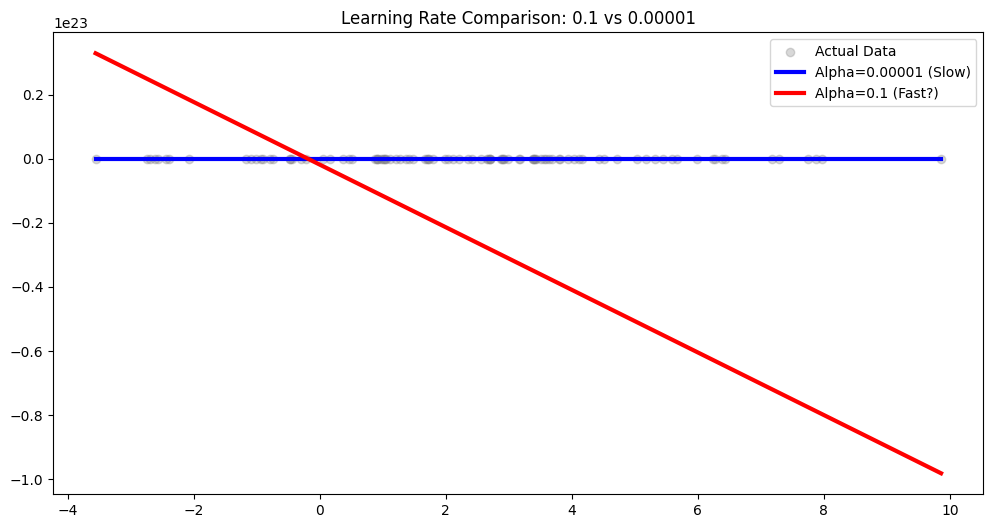

Alpha 0.00001 的最終參數: w=1.735434109987476, b=0.1049480488431178
Alpha 0.1 的最終參數: -9.766535486521127e+21


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 產生與之前相同的資料(我沒改種子)
np.random.seed(42)
X = 2 - 3 * np.random.normal(0, 1, 100)
y = X - 2 * (X ** 2) + 0.5 * (X ** 3) + np.random.normal(-3, 3, 100)
n = float(len(X))

# 定義手寫 GD 函數以便重複使用
def manual_gd(X, y, alpha, epochs=1000):
    w, b = 0.0, 0.0
    for i in range(epochs):
        y_pred = w * X + b
        dw = (-2/n) * np.sum(X * (y - y_pred))
        db = (-2/n) * np.sum(y - y_pred)
        w = w - alpha * dw
        b = b - alpha * db
        # 如果數值爆炸了，提早停止
        if np.isnan(w) or np.isinf(w):
            return "Exploded", "Exploded"
    return w, b

# 2. 執行兩種實驗
# 實驗 A: 學習率 0.1 (通常會爆炸)
w_high, b_high = manual_gd(X, y, alpha=0.1, epochs=100)

# 實驗 B: 學習率 0.00001 (緩慢)
w_low, b_low = manual_gd(X, y, alpha=0.00001, epochs=1000)

# 3. 繪圖比對
X_seq = np.linspace(X.min(), X.max(), 300)
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='gray', alpha=0.3, label='Actual Data')

# 繪製 alpha = 0.00001 的結果
if w_low != "Exploded":
    plt.plot(X_seq, w_low * X_seq + b_low, color='blue', label=f'Alpha=0.00001 (Slow)', linewidth=3)

# 繪製 alpha = 0.1 的結果 (如果沒爆炸的話)
if w_high == "Exploded":
    plt.text(0, 0, "Alpha=0.1 Exploded (NaN)", fontsize=15, color='red', ha='center', bbox=dict(facecolor='white', alpha=0.8))
else:
    plt.plot(X_seq, w_high * X_seq + b_high, color='red', label=f'Alpha=0.1 (Fast?)', linewidth=3)

plt.title("Learning Rate Comparison: 0.1 vs 0.00001")
plt.legend()
plt.show()

print(f"Alpha 0.00001 的最終參數: w={w_low}, b={b_low}")
print(f"Alpha 0.1 的最終參數: {w_high}")

1. 學習率 ($\alpha$) 的觀察：$\alpha = 0.1$ (太高)： 權重更新步子跨得太大，模型可能會在最小值附近「左右橫跳」甚至直接炸掉（發散 如上圖發散到爆炸了），導致損失函數越來越大。$\alpha = 0.00001$ (太低)： 步子邁得太小，雖然穩定，但會導致收斂速度極慢。你可能需要跑幾萬次迭代才能看到模型變聰明，這在實務上非常浪費計算資源。

2. 為何 SGD 在大數據時更有效率？
Batch GD： 每次更新權重都要讀取**所有**資料來算梯度。當你有很多筆資料時，更新一步就要等很久。
SGD (隨機梯度下降)： 每次只抓一筆或一小群 (Mini-batch)資料就更新權重。雖然路徑會比較歪（有雜訊），但它更新速度極快，且這種隨機性有時能幫模型跳出局部最小值 (Local Minima)。

##練習 3：過度擬合觀察

請修改範例程式碼中的 ```PolynomialFeatures(degree=3)```，將 ```degree``` 改為 ```15```。

觀察繪製出的曲線是否變得極度扭曲？

比較其「訓練集分數」與「測試集分數」。若訓練集分數遠高於測試集，這代表發生了什麼現象？

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.867e+02, tolerance: 1.611e+01
  model = cd_fast.enet_coordinate_descent(


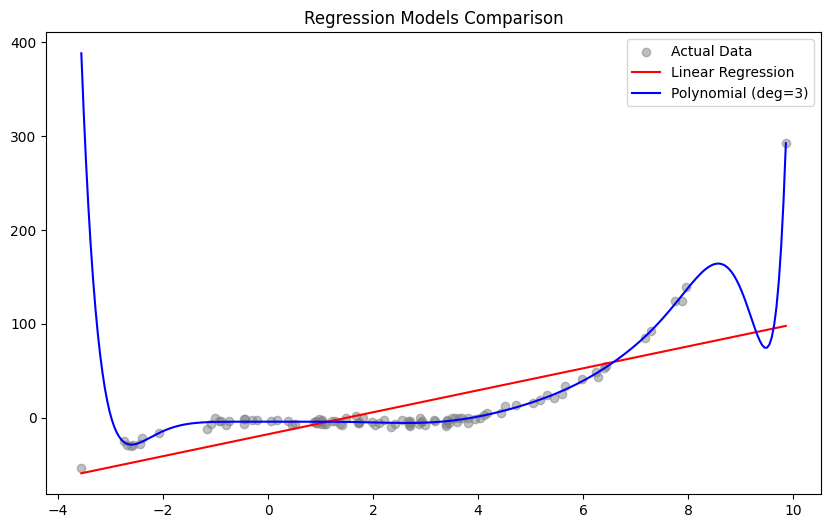

Linear Score: 0.1790
Polynomial Score: -24.9078


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 1. 產生模擬資料 (包含一些雜訊)
np.random.seed(42)
X = 2 - 3 * np.random.normal(0, 1, 100)
y = X - 2 * (X ** 2) + 0.5 * (X ** 3) + np.random.normal(-3, 3, 100)
X = X[:, np.newaxis] # 轉為 2D array 以符合 sklearn 要求

# 2. 資料切分 (80% 訓練, 20% 測試)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 實作：簡單線性迴歸 ---
lin_regr = linear_model.LinearRegression()
lin_regr.fit(X_train, y_train)

# --- 實作：多項式迴歸 (設定為 3 次方) ---
# 使用 Pipeline 簡化特徵轉換與迴歸流程
poly_model = make_pipeline(PolynomialFeatures(degree=15), linear_model.LinearRegression()) #改成15了
poly_model.fit(X_train, y_train)

# --- 實作：Lasso 正規化 (防止過度擬合) ---
lasso_model = make_pipeline(PolynomialFeatures(degree=10), linear_model.Lasso(alpha=1.0))
lasso_model.fit(X_train, y_train)

# 3. 視覺化比較
X_seq = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='gray', alpha=0.5, label='Actual Data')
plt.plot(X_seq, lin_regr.predict(X_seq), color='red', label='Linear Regression')
plt.plot(X_seq, poly_model.predict(X_seq), color='blue', label='Polynomial (deg=3)')
plt.legend()
plt.title("Regression Models Comparison")
plt.show()

# 4. 評估模型效能 (R-squared)
print(f"Linear Score: {lin_regr.score(X_test, y_test):.4f}")
print(f"Polynomial Score: {poly_model.score(X_test, y_test):.4f}")

1. 曲線變化：
當你將 degree 設為 15，藍色曲線確實變得超扭，而是為了"遷就"每一個帶有雜訊的數據點而產生劇烈的上下抖動。

2. 分數比較與現象：
你的「訓練集分數」會非常高（接近 1.0），但「測試集分數」會大幅下降，甚至變成負值。

結論： 這就是典型的 過擬合。模型過度關注訓練資料中的雜訊，反而失去了處理未見過資料的泛化能力。

##練習 4：正規化實戰

針對練習 3 產生的高次式模型，請改用 ```linear_model.Ridge(alpha=10)``` 進行訓練。

觀察加入 L2 懲罰項後，測試集的分數是否有所提升？

在什麼樣的情況下，你會選擇使用 Lasso (L1) 而不是 Ridge (L2)？(提示：考慮特徵數量的篩選)。

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.39163e-29): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.350e+02, tolerance: 1.611e+01
  model = cd_fast.enet_coordinate_descent(


【測試集分數對比 (越接近1越好)】
1. Linear Score: 0.1790
2. Polynomial (deg=15) Score: -24.9078  <-- 通常很慘或為負數
3. Ridge (deg=15, alpha=10) Score: -54.5125  <-- 分數回升
4. Lasso (deg=15, alpha=1) Score: 0.9574
----------------------------------------
【Lasso 特徵篩選觀察】
15 次方模型共有 16 個特徵係數 (包含截距)。
Lasso (L1) 將其中 2 個不重要的係數直接變成了 0！


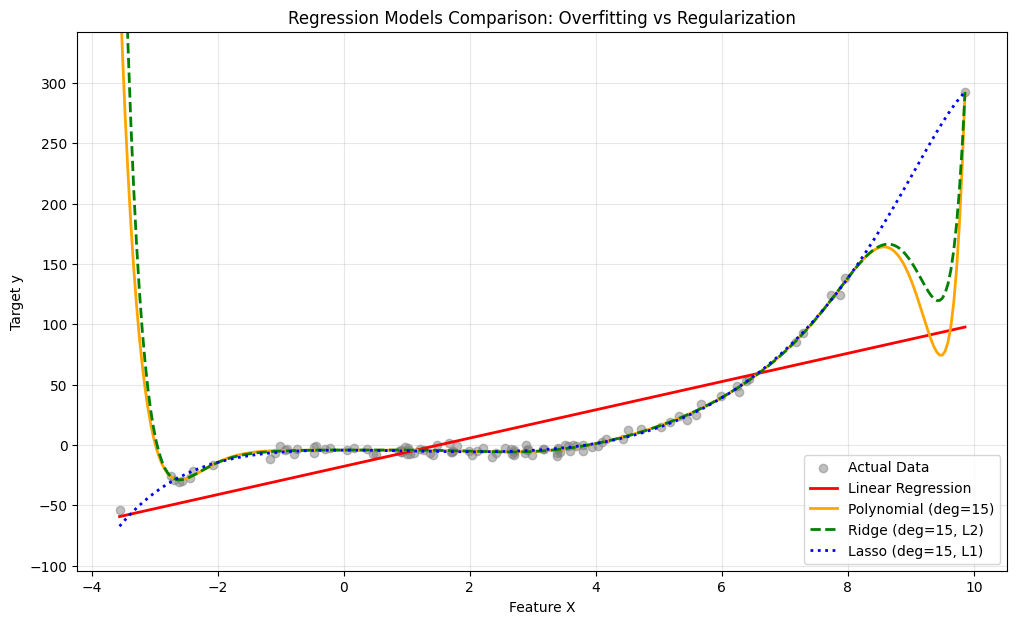

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

# ==========================================
# 1. 產生模擬資料 (包含一些雜訊)
# ==========================================
np.random.seed(42)
X = 2 - 3 * np.random.normal(0, 1, 100)
# 隱藏的真實規律包含 X, X^2, X^3
y = X - 2 * (X ** 2) + 0.5 * (X ** 3) + np.random.normal(-3, 3, 100)
X = X[:, np.newaxis] # 轉為 2D array 以符合 sklearn 要求

# 2. 資料切分 (80% 訓練, 20% 測試)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 3. 建立與訓練各種迴歸模型
# ==========================================
# (A) 簡單線性迴歸 (Underfitting 欠擬合)
lin_regr = linear_model.LinearRegression()
lin_regr.fit(X_train, y_train)

# (B) 15次方多項式迴歸 (Overfitting 過度擬合)
poly_model = make_pipeline(PolynomialFeatures(degree=15), linear_model.LinearRegression())
poly_model.fit(X_train, y_train)

# (C) Ridge 正規化 (L2) - 抑制過大的權重
ridge_model = make_pipeline(PolynomialFeatures(degree=15), linear_model.Ridge(alpha=10.0))
ridge_model.fit(X_train, y_train)

# (D) Lasso 正規化 (L1) - 特徵篩選 (加入 max_iter 避免收斂警告)
lasso_model = make_pipeline(PolynomialFeatures(degree=15), linear_model.Lasso(alpha=1.0, max_iter=100000))
lasso_model.fit(X_train, y_train)

# ==========================================
# 4. 評估模型效能 (R-squared 決定係數)
# ==========================================
print("【測試集分數對比 (越接近1越好)】")
print(f"1. Linear Score: {lin_regr.score(X_test, y_test):.4f}")
print(f"2. Polynomial (deg=15) Score: {poly_model.score(X_test, y_test):.4f}  <-- 通常很慘或為負數")
print(f"3. Ridge (deg=15, alpha=10) Score: {ridge_model.score(X_test, y_test):.4f}  <-- 分數回升")
print(f"4. Lasso (deg=15, alpha=1) Score: {lasso_model.score(X_test, y_test):.4f}")
print("-" * 40)

# 觀察 Lasso 的特徵篩選效果
lasso_coefs = lasso_model.named_steps['lasso'].coef_
zero_coefs_count = np.sum(lasso_coefs == 0)
print(f"【Lasso 特徵篩選觀察】")
print(f"15 次方模型共有 {len(lasso_coefs)} 個特徵係數 (包含截距)。")
print(f"Lasso (L1) 將其中 {zero_coefs_count} 個不重要的係數直接變成了 0！")

# ==========================================
# 5. 視覺化比較
# ==========================================
# 產生平滑的 X 序列用來畫預測曲線
X_seq = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

plt.figure(figsize=(12, 7))
plt.scatter(X, y, color='gray', alpha=0.5, label='Actual Data')

# 畫出各個模型的預測線
plt.plot(X_seq, lin_regr.predict(X_seq), color='red', label='Linear Regression', linewidth=2)
plt.plot(X_seq, poly_model.predict(X_seq), color='orange', label='Polynomial (deg=15)', linewidth=2)
plt.plot(X_seq, ridge_model.predict(X_seq), color='green', label='Ridge (deg=15, L2)', linewidth=2, linestyle='--')
plt.plot(X_seq, lasso_model.predict(X_seq), color='blue', label='Lasso (deg=15, L1)', linewidth=2, linestyle=':')

# 限制 Y 軸範圍，避免被 Polynomial 15 次方的極端值拉大導致看不清
plt.ylim(y.min() - 50, y.max() + 50)

plt.title("Regression Models Comparison: Overfitting vs Regularization")
plt.xlabel("Feature X")
plt.ylabel("Target y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

1. Ridge (L2) 的效果：加入 ```Ridge(alpha=10)``` 後，會發現原本扭曲的 15 次方曲線變得平緩許多，測試集分數通常會明顯回升。這是因為 L2 懲罰項會沒收過大的權重，強迫模型不要對單一特徵過度敏感。

2. Lasso (L1) vs. Ridge (L2) 的選擇：

| 特性 | Ridge (L2) | Lasso (L1) |
| :--- | :--- | :--- |
| **懲罰方式** | 權重的平方和 | 權重的絕對值和 |
| **權重處理** | 將權重趨近於 0，但不會剛好等於 0 | 會將不重要的權重**直接歸零** |
| **使用時機** | 當你認為所有特徵都有一點貢獻時 | 當你特徵超多，且懷疑其中只有少數幾個有用時 |

<br>總而言之： 如果你想做「特徵篩選 (Feature Selection)」，選 Lasso；如果你只是想防止模型變太激進，選 Ridge。